# Architecture Internals — Winograd-Friendly Pareto Models

Detailed per-model block diagrams for the 4 models that sit on the
accuracy/size/quantization Pareto frontier and are built entirely from
1x1/3x3 convolutions (no 5x5/11x11 anywhere) — spanning Phase 3
(compensation mechanisms), Phase 4 (final architecture), and Phase 9
(bypass ablation). Companion figure to the tables in `docs/plans/BEST_MODELS.md`
and `results/results_aggregate/results_cross_phase.csv`: this notebook
shows *how* each mechanism is built, not just its accuracy/size numbers.

Each model gets its own vertical diagram (input at top, classifier head at
bottom) with real per-stage output resolution, parameter counts, and
squeeze/expand/reduce role labels — computed from the actual loaded
weights via forward hooks, not eyeballed from the source.

## Configuration

In [1]:
import gzip
import sys
from pathlib import Path

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def find_project_root(start: Path | None = None):
    """Walk upward until the repository root is found."""
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "results").exists() and (candidate / "models").exists():
            return candidate
    return start


project_root = find_project_root()
sys.path.insert(0, str(project_root))  # so `import ml`/`import models` resolve regardless of kernel cwd

import ml.model_registrations  # noqa: F401  (populates MODEL_REGISTRY)
from ml import MODEL_REGISTRY
from ml.quantization import load_best_model
from ml.plotting import apply_report_style, BLUE, RED, GREEN, AMBER, NEUTRAL, TEXT_PRIMARY, TEXT_SECONDARY, GRID
from models.compensation import _AlexBottleneck, _FireModule
from models.final_architecture import _FireResBlock

apply_report_style()

PCAD_DIR = project_root / "outputs" / "pcad"
LARGE_SCALE_DIR = PCAD_DIR / "archive_legacy_phases" / "phase_4_5_large_scale"
FIGURES_DIR = project_root / "results" / "figures_generated" / "phase_5_cross_phase_analysis"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


device = torch.device("cpu")
INPUT_HW = (64, 64)  # Tiny ImageNet-200 input resolution
NUM_CLASSES = 200
print(f"Project root: {project_root}")

/home/rafael/Documents/alexnet_rafael/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/rafael/Documents/alexnet_rafael


## Load Models

Real trained weights (not just class definitions) so channel counts and
parameter/shape annotations in the diagram are exact. `AlexNetFinalFireResidual`
only has a gzipped checkpoint on disk — `load_best_model()` can't read
`.pth.gz`, so it gets a 3-line local fallback rather than a new decompress
helper in `ml/checkpoint.py` (nothing else needs one yet).

In [2]:
CHECKPOINT_DIRS = {
    "alexnet_bottleneck": LARGE_SCALE_DIR / "alexnet_bottleneck" / "checkpoints",
    "alexnet_fire": LARGE_SCALE_DIR / "alexnet_fire" / "checkpoints",
    "alexnet_fire_bypass": PCAD_DIR / "phase_9_bypass_ablation" / "fire_bypass_large_scale"
                            / "alexnet_fire_bypass" / "checkpoints",
}
FIRE_RESIDUAL_CKPT_GZ = (LARGE_SCALE_DIR / "alexnet_final_fire_residual"
                          / "checkpoints" / "alexnet_final_fire_residual_best.pth.gz")


def load_gz_checkpoint(ctor, gz_path, device):
    model = ctor()
    with gzip.open(gz_path, "rb") as f:
        ckpt = torch.load(f, map_location=str(device), weights_only=False)
    state = ckpt.get("model_state_dict", ckpt)
    model.load_state_dict(state)
    return model.to(device).eval()


models = {}
for name in ["alexnet_bottleneck", "alexnet_fire", "alexnet_fire_bypass"]:
    ctor = MODEL_REGISTRY[name]["ctor"]
    models[name] = load_best_model(name, ctor, CHECKPOINT_DIRS[name], device)

models["alexnet_final_fire_residual"] = load_gz_checkpoint(
    MODEL_REGISTRY["alexnet_final_fire_residual"]["ctor"], FIRE_RESIDUAL_CKPT_GZ, device,
)

for name, m in models.items():
    n_params = sum(p.numel() for p in m.parameters()) / 1e6
    print(f"{name}: loaded, {n_params:.3f}M params")

alexnet_bottleneck: loaded, 0.385M params
alexnet_fire: loaded, 0.516M params
alexnet_fire_bypass: loaded, 0.516M params
alexnet_final_fire_residual: loaded, 0.699M params


## Known Result Metrics

Hand-copied from the sources below (three different CSV schemas — not worth a generic joiner for 4 title annotations; the Phase 5/9 notebooks already own that comparison job).

In [3]:
# NOTE: sizes are WEIGHTS-ONLY (serialized state_dict), per the 2026-09-02 fix in
# ml/reporting.py; they previously reported the training checkpoint (~3x, AdamW state).
# alexnet_fire_bypass top-1 also corrected: 49.03 predated the Trainer.fit() fix.
# Keep in sync with report/generate_architecture_figures.py.
METRICS = {
    # results/results_aggregate/results_cross_phase.csv -- Phase 3, "alexnet_bottleneck" row
    "alexnet_bottleneck": {"top1_fp32": 44.62, "size_mb": 1.51},
    # results/results_aggregate/results_cross_phase.csv -- Phase 3, "alexnet_fire" row
    "alexnet_fire": {"top1_fp32": 43.98, "size_mb": 2.01},
    # results/phase_4_compression_and_final_architecture/final_comparison.csv -- FP32 row
    "alexnet_final_fire_residual": {"top1_fp32": 49.79, "size_mb": 2.71},
    # outputs/pcad/phase_9_bypass_ablation/fire_bypass_large_scale/alexnet_fire_bypass/results/alexnet_fire_bypass_summary.json -- fp32_top1/fp32_size_mb
    "alexnet_fire_bypass": {"top1_fp32": 50.57, "size_mb": 2.01},
}

## Extract Architecture Stages

Each model is entirely built from `nn.Conv2d` wrapped in one of three
compensation blocks (`_AlexBottleneck`, `_FireModule`, `_FireResBlock`),
plus pooling. A block's residual/bypass connection isn't a separate module —
it's a `skip_add = FloatFunctional()` attribute set in `__init__` — so
`hasattr(block, "skip_add")` is the generic signal used here instead of
hardcoding which model has which topology. Each conv's role within its
block (squeeze/expand/reduce) comes from a small lookup by block class,
since that's fixed by the architecture, not learned.

`AlexNetFireBypass` is the one exception: its bypass lives on the *model*,
not a block (`fire4`/`fire5` are two plain `_FireModule`s with the skip
added between them in `forward()`), so that one gets a 2-stage
`residual_span` after the walk instead of the usual 1-stage span.

Every stage also keeps a reference to its real `nn.Module` so the next cell
can hook it and record the actual output shape from a forward pass — no
manual stride/padding arithmetic to get wrong.

In [4]:
STAGE_BLOCK_TYPES = (_AlexBottleneck, _FireModule, _FireResBlock)

# Fixed by architecture (order convs are registered in __init__), not learned.
ROLE_LABELS = {
    "_AlexBottleneck": ["reduce", "conv", "expand"],
    "_FireModule": ["squeeze", "expand1", "expand3"],
    "_FireResBlock": ["squeeze", "expand1", "expand3", "proj"],
}


def stage_from_block(block):
    convs = [m for m in block.modules() if isinstance(m, nn.Conv2d)]
    cls = type(block).__name__
    roles = ROLE_LABELS.get(cls, [])
    roles = roles[:len(convs)] if len(roles) >= len(convs) else [""] * len(convs)
    return {
        "type": cls.lstrip("_"),
        "kernels": [c.kernel_size[0] for c in convs],
        "roles": roles,
        "in_ch": convs[0].in_channels,
        "out_ch": convs[-1].out_channels,
        "residual_span": 1 if hasattr(block, "skip_add") else 0,
        "n_params": sum(p.numel() for p in block.parameters()),
        "module": block,
    }


def get_stages(model):
    """Ordered list of stages: compensation blocks, bare stem convs, and pool markers."""
    stages = []

    def walk(module):
        for child in module.children():
            if isinstance(child, STAGE_BLOCK_TYPES):
                stages.append(stage_from_block(child))
            elif isinstance(child, nn.MaxPool2d):
                k = child.kernel_size if isinstance(child.kernel_size, int) else child.kernel_size[0]
                s = child.stride if isinstance(child.stride, int) else child.stride[0]
                stages.append({"type": "pool", "pool_kernel": k, "pool_stride": s, "module": child})
            elif isinstance(child, nn.Conv2d):
                stages.append({
                    "type": "conv", "kernels": [child.kernel_size[0]], "roles": [""],
                    "in_ch": child.in_channels, "out_ch": child.out_channels,
                    "residual_span": 0, "n_params": sum(p.numel() for p in child.parameters()),
                    "module": child,
                })
            else:
                walk(child)  # containers (Sequential, the model itself) or unrelated leaves

    walk(model)
    if hasattr(model, "skip_add") and stages:
        stages[-1]["residual_span"] = 2  # AlexNetFireBypass: bypass spans fire4 -> fire5
    return stages


def annotate_output_shapes(model, stages, input_hw=INPUT_HW):
    """Attach each stage's real (C, H, W) output shape via forward hooks -- one dummy forward pass."""
    handles = []
    for stage in stages:
        def hook(_mod, _inp, out, stage=stage):
            stage["out_shape"] = tuple(out.shape[1:])
            # Trust the real forward pass over static analysis: for Fire-style blocks the
            # true out_ch is expand1+expand3 concatenated, not just the last conv's out_channels.
            stage["out_ch"] = out.shape[1]
        handles.append(stage["module"].register_forward_hook(hook))
    with torch.no_grad():
        model(torch.zeros(1, 3, *input_hw))
    for h in handles:
        h.remove()
    return stages


def head_info(model, stages):
    """Real classifier-head shape/param facts: GAP input shape + the actual Linear layer's size."""
    last = next(s for s in reversed(stages) if s["type"] != "pool")
    c, h, w = last["out_shape"]
    linear = model.classifier[-1]
    return {
        "in_ch": c, "in_hw": (h, w), "out_features": linear.out_features,
        "n_params": sum(p.numel() for p in linear.parameters()),
    }


STAGES = {name: annotate_output_shapes(models[name], get_stages(models[name])) for name in models}
HEADS = {name: head_info(models[name], STAGES[name]) for name in models}
for name, stages in STAGES.items():
    n_blocks = sum(1 for s in stages if s["type"] != "pool")
    print(f"{name}: {n_blocks} blocks, {len(stages)} total stages")

alexnet_bottleneck: 5 blocks, 7 total stages
alexnet_fire: 5 blocks, 7 total stages
alexnet_fire_bypass: 5 blocks, 7 total stages
alexnet_final_fire_residual: 5 blocks, 7 total stages


## Draw Architecture Diagrams

One horizontal diagram per model — input on the left, classifier head on
the right, residual/bypass arcs bowing above the row. Each stage box shows:
block type, real output shape (from the forward hooks above), parameter
count, and one labeled color chip per internal conv (role + kernel size),
with a `BN · ReLU` footer since every conv in these blocks is followed by
both. Horizontal instead of vertical so two models fit per report page
without shrinking any one diagram into illegibility.

**Simplification, called out explicitly:** Fire's parallel `expand1`/`expand3`
branches are drawn as adjacent chips, not spatially forked and concatenated —
the role labels make the parallel structure legible without the extra
drawing code a true branch/concat rendering would need.

In [5]:
KERNEL_COLORS = {1: NEUTRAL, 3: GREEN}  # 1x1 grey, 3x3 green (the Winograd-friendly core)
# Block-type border color + corner tag -- lets a diagram that mixes block types (only
# AlexNetFinalFireResidual does: plain stem conv + FireResBlock stages) read at a glance which
# stage is which, without needing the caption. Bottleneck/Fire/FireBypass are uniform internally,
# so this is a no-op visual change for them (every block gets the same tag/border throughout).
BLOCK_TYPE_STYLE = {
    "conv": (BLUE, "STEM"),
    "AlexBottleneck": (TEXT_SECONDARY, "BOTTLENECK"),
    "FireModule": (AMBER, "FIRE"),
    "FireResBlock": (AMBER, "FIRE"),
}

# Fixed box height for every stage (input/blocks/head); width grows left-to-right with the model
# instead of height growing top-to-bottom -- the whole point of the horizontal layout.
BOX_H = 3.0
HEADER_H, FOOTER_H, CHIP_PAD = 0.85, 0.22, 0.05
BLOCK_W, POOL_W, GAP = 2.05, 0.65, 0.32
INPUT_W, HEAD_W = 1.5, 1.9


def fmt_params(n):
    return f"{n / 1e3:.1f}K" if n < 1e6 else f"{n / 1e6:.2f}M"


def total_width(stages):
    """Sum of every stage's column width + gaps -- drives the per-model figsize below."""
    x = INPUT_W + GAP
    for s in stages:
        x += (POOL_W if s["type"] == "pool" else BLOCK_W) + GAP
    return x + HEAD_W


def draw_input_box(ax, x_left, x_right, input_hw):
    ax.add_patch(mpatches.FancyBboxPatch((x_left, 0), x_right - x_left, BOX_H, boxstyle="round,pad=0.02",
                 linewidth=1.1, edgecolor=TEXT_PRIMARY, facecolor=GRID, zorder=2))
    cx = (x_left + x_right) / 2
    ax.text(cx, 0.16, "Input", fontsize=9, fontweight="bold", va="top", ha="center", color=TEXT_PRIMARY)
    ax.text(cx, BOX_H / 2, f"3×{input_hw[0]}×{input_hw[1]}", fontsize=9.5, va="center", ha="center",
            fontweight="bold", color=GREEN)
    ax.text(cx, BOX_H - 0.14, "RGB · Tiny\nImageNet-200", fontsize=6, va="bottom", ha="center",
            color=TEXT_SECONDARY, style="italic", linespacing=1.3)


def draw_head_box(ax, x_left, x_right, head):
    HEAD_COLOR = BLUE
    ax.add_patch(mpatches.FancyBboxPatch((x_left, 0), x_right - x_left, BOX_H, boxstyle="round,pad=0.02",
                 linewidth=1.1, edgecolor=TEXT_PRIMARY, facecolor="white", zorder=2))
    cx = (x_left + x_right) / 2
    ax.text(cx, 0.14, "Classifier Head", fontsize=8, fontweight="bold", va="top", ha="center", color=TEXT_PRIMARY)

    c, (fh, fw) = head["in_ch"], head["in_hw"]
    info = f"{c}×{fh}×{fw} in · {head['out_features']} out\n{fmt_params(head['n_params'])} params"
    ax.text(cx, 0.46, info, fontsize=6.2, va="top", ha="center", color=TEXT_SECONDARY, linespacing=1.4)

    chips = [("GAP", f"→ {c}×1×1"), ("Flatten", f"→ {c}"), ("Linear", f"→ {head['out_features']}")]
    chip_top, chip_bot = 0.95, BOX_H - 0.12
    chip_h = (chip_bot - chip_top) / len(chips)
    chip_left, chip_right = x_left + 0.1, x_right - 0.1
    for j, (nm, detail) in enumerate(chips):
        cy = chip_top + j * chip_h
        ax.add_patch(mpatches.Rectangle((chip_left, cy), chip_right - chip_left, chip_h - 0.06,
                     facecolor=HEAD_COLOR, edgecolor="white", lw=0.5, zorder=3))
        ax.text((chip_left + chip_right) / 2, cy + (chip_h - 0.06) / 2, f"{nm}  {detail}",
                ha="center", va="center", fontsize=6.3, fontweight="bold", color="white", zorder=4)


def draw_architecture(ax, stages, title, metrics, head, input_hw=INPUT_HW):
    x = 0.0
    input_span = (x, x + INPUT_W)
    x = input_span[1] + GAP

    xs = []  # (x_left, x_right) per stage, left-to-right data coords
    for stage in stages:
        w = POOL_W if stage["type"] == "pool" else BLOCK_W
        xs.append((x, x + w))
        x += w + GAP

    head_span = (x, x + HEAD_W)
    total_w = head_span[1]

    draw_input_box(ax, *input_span, input_hw)
    draw_head_box(ax, *head_span, head)

    for i, stage in enumerate(stages):
        x_left, x_right = xs[i]

        if stage["type"] == "pool":
            c, h, w = stage.get("out_shape", (None, None, None))
            label = f"MaxPool {stage['pool_kernel']}×{stage['pool_kernel']}\nstride {stage['pool_stride']}"
            if h is not None:
                label += f"\n→ {h}×{w}"
            ax.plot([x_left, x_right], [BOX_H / 2, BOX_H / 2], ":", color=NEUTRAL, lw=1.4, zorder=1)
            ax.text((x_left + x_right) / 2, BOX_H / 2 - 0.55, label, ha="center", va="center",
                    fontsize=8, color=TEXT_SECONDARY, linespacing=1.25)
            continue

        border_color, type_tag = BLOCK_TYPE_STYLE.get(stage["type"], (TEXT_PRIMARY, ""))
        ax.add_patch(mpatches.FancyBboxPatch((x_left, 0), x_right - x_left, BOX_H, boxstyle="round,pad=0.02",
                     linewidth=2.0, edgecolor=border_color, facecolor="white", zorder=2))
        if type_tag:
            ax.text(x_right - 0.06, 0.05, type_tag, fontsize=5.3, fontweight="bold",
                    ha="right", va="top", color=border_color, zorder=4)

        c, h, w = stage.get("out_shape", (stage["out_ch"], None, None))
        info = f'{stage["in_ch"]}→{stage["out_ch"]} ch'
        if h is not None:
            info += f"  ·  {h}×{w}"
        info += f"\n{fmt_params(stage['n_params'])} params"
        ax.text((x_left + x_right) / 2, 0.16, info, fontsize=6.3, va="top", ha="center",
                color=TEXT_SECONDARY, linespacing=1.5)

        kernels, roles = stage["kernels"], stage["roles"]
        n = len(kernels)
        chip_top, chip_bot = HEADER_H, BOX_H - FOOTER_H
        chip_w = (x_right - x_left - 0.2) / n
        for j, (k, role) in enumerate(zip(kernels, roles)):
            cx0 = x_left + 0.1 + j * chip_w
            ax.add_patch(mpatches.Rectangle((cx0, chip_top), chip_w - CHIP_PAD, chip_bot - chip_top,
                         facecolor=KERNEL_COLORS.get(k, GRID), edgecolor="white", lw=0.5, zorder=3))
            label = f"{role}\n{k}×{k}" if role else f"{k}×{k}"
            ax.text(cx0 + (chip_w - CHIP_PAD) / 2, (chip_top + chip_bot) / 2, label,
                    ha="center", va="center", fontsize=6.0, fontweight="bold", color="white",
                    linespacing=1.3, zorder=4)

        ax.text((x_left + x_right) / 2, BOX_H - 0.06, "BN · ReLU each", fontsize=5.6, color=TEXT_SECONDARY,
                ha="center", va="bottom", style="italic")

        span = stage.get("residual_span", 0)
        if span:
            x_start = xs[i - span + 1][0]
            # rad is negative because ax.invert_yaxis() (used so the network reads left-to-right
            # with input/header text at the top of each box) flips arc3's bow direction -- positive
            # rad bows *down into* the box and hides under its fill (verified empirically).
            arc = mpatches.FancyArrowPatch((x_start, -0.08), (x_right, -0.08),
                                            connectionstyle="arc3,rad=-0.35",
                                            arrowstyle="-|>", mutation_scale=10,
                                            color=RED, lw=1.5, zorder=5)
            ax.add_patch(arc)

    ax.set_xlim(-0.15, total_w + 0.15)
    ax.set_ylim(-1.0, BOX_H + 0.15)
    ax.invert_yaxis()
    ax.axis("off")

    acc, size = metrics.get("top1_fp32"), metrics.get("size_mb")
    subtitle = f"{acc:.1f}% top-1 · {size:.2f} MB (FP32)" if acc is not None else ""
    ax.set_title(f"{title}   —   {subtitle}", fontsize=12, fontweight="bold", pad=8)


def add_legend(fig, stages):
    kernel_handles = [mpatches.Patch(color=c, label=f"{k}×{k} conv") for k, c in KERNEL_COLORS.items()]
    kernel_handles.append(plt.Line2D([0], [0], color=RED, lw=1.5, label="residual / bypass skip"))
    present_types = {s["type"] for s in stages if s["type"] != "pool"}
    type_handles = [
        mpatches.Patch(facecolor="white", edgecolor=color, linewidth=2, label=f"{tag.title()} block")
        for stype, (color, tag) in BLOCK_TYPE_STYLE.items() if stype in present_types
    ]
    fig.legend(handles=kernel_handles + type_handles, loc="lower center", ncol=5, fontsize=8.5,
               bbox_to_anchor=(0.5, -0.02), frameon=False)


def save_model_figure(name, title):
    stages = STAGES[name]
    fig_w = total_width(stages) + 0.3
    fig_h = BOX_H + 1.15  # + room for the title above and the legend below
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    draw_architecture(ax, stages, title, METRICS[name], HEADS[name])
    add_legend(fig, stages)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.savefig(FIGURES_DIR / f"architecture_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

### AlexNetBottleneck (Phase 3)

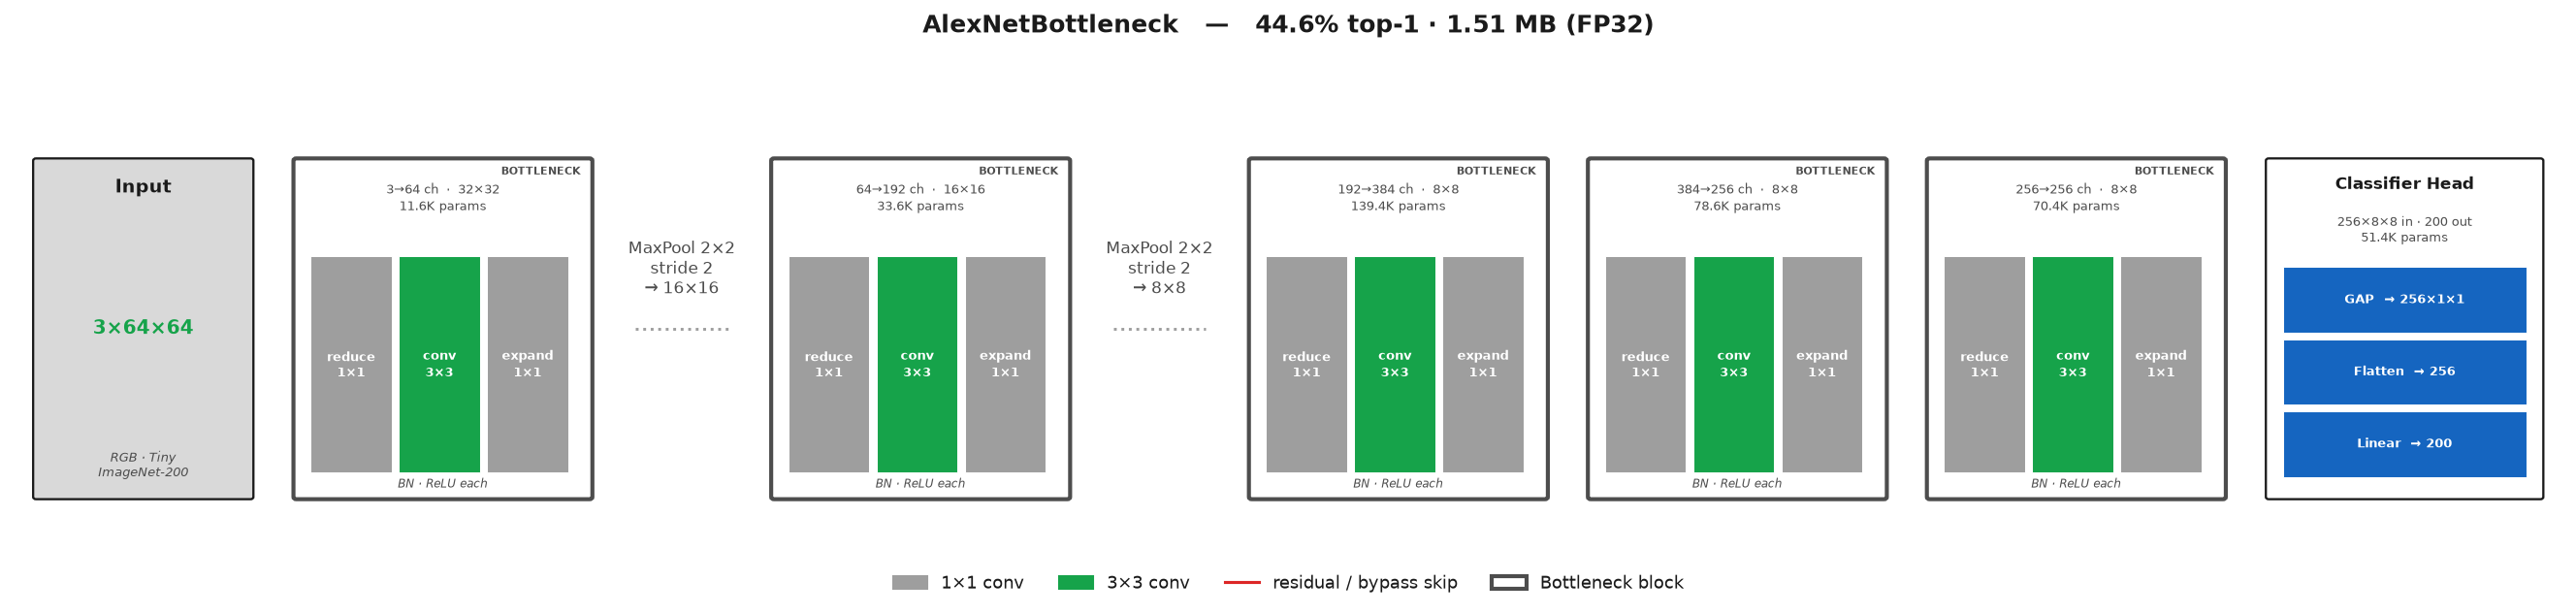

In [6]:
save_model_figure("alexnet_bottleneck", "AlexNetBottleneck")

### AlexNetFire (Phase 3)

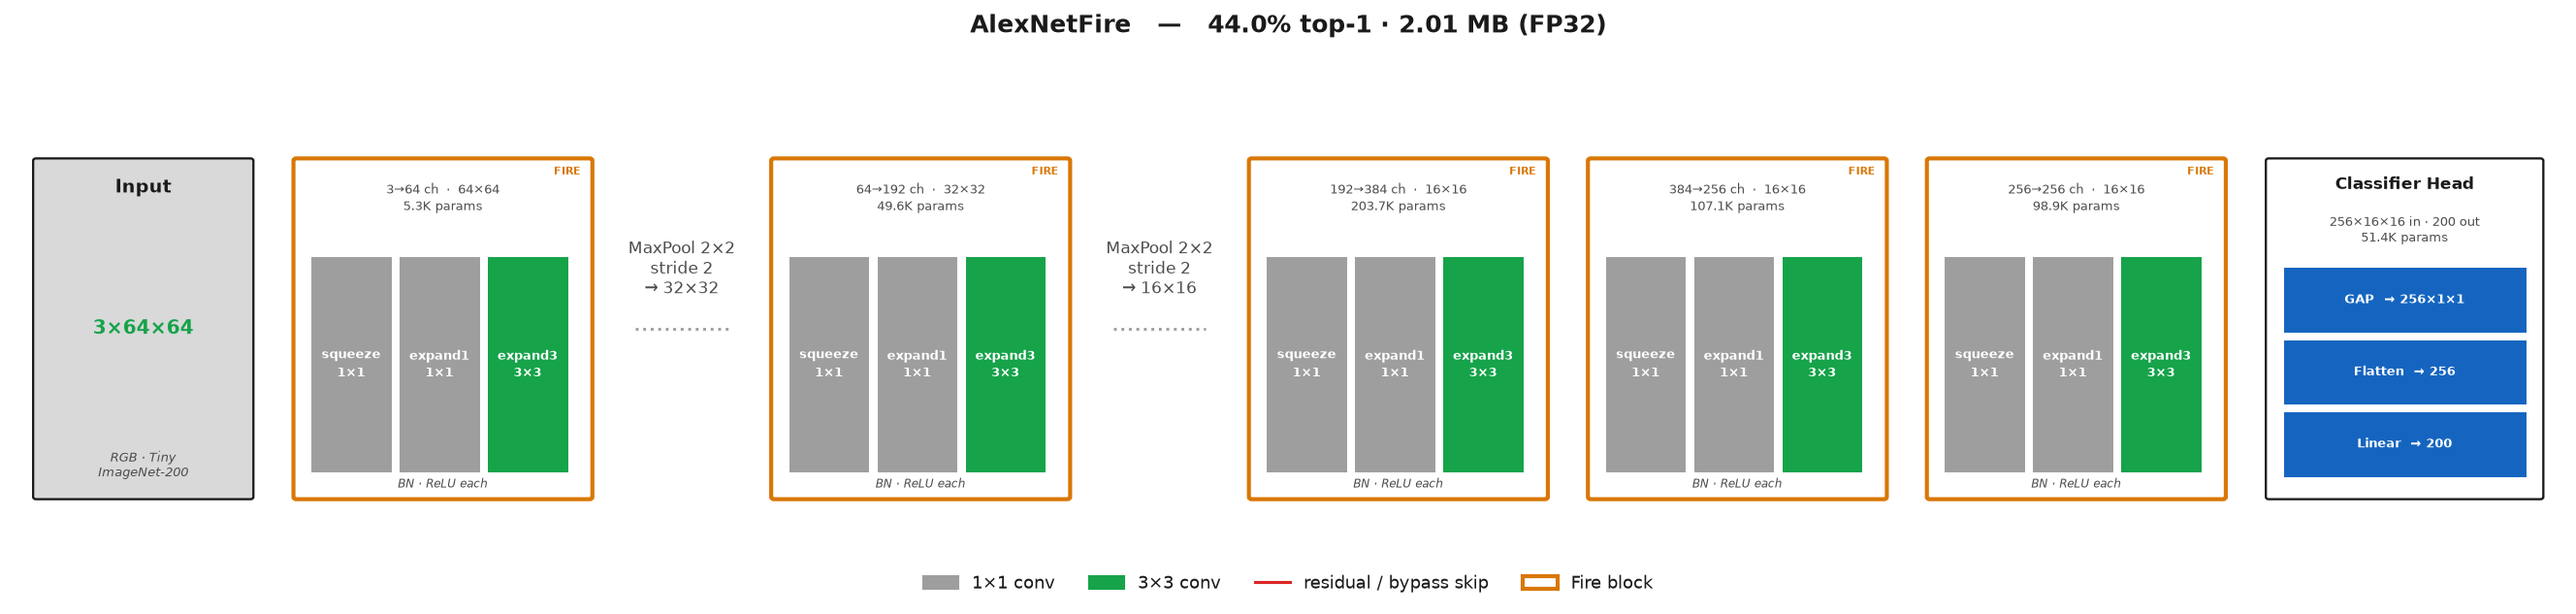

In [7]:
save_model_figure("alexnet_fire", "AlexNetFire")

### AlexNetFinalFireResidual (Phase 4)

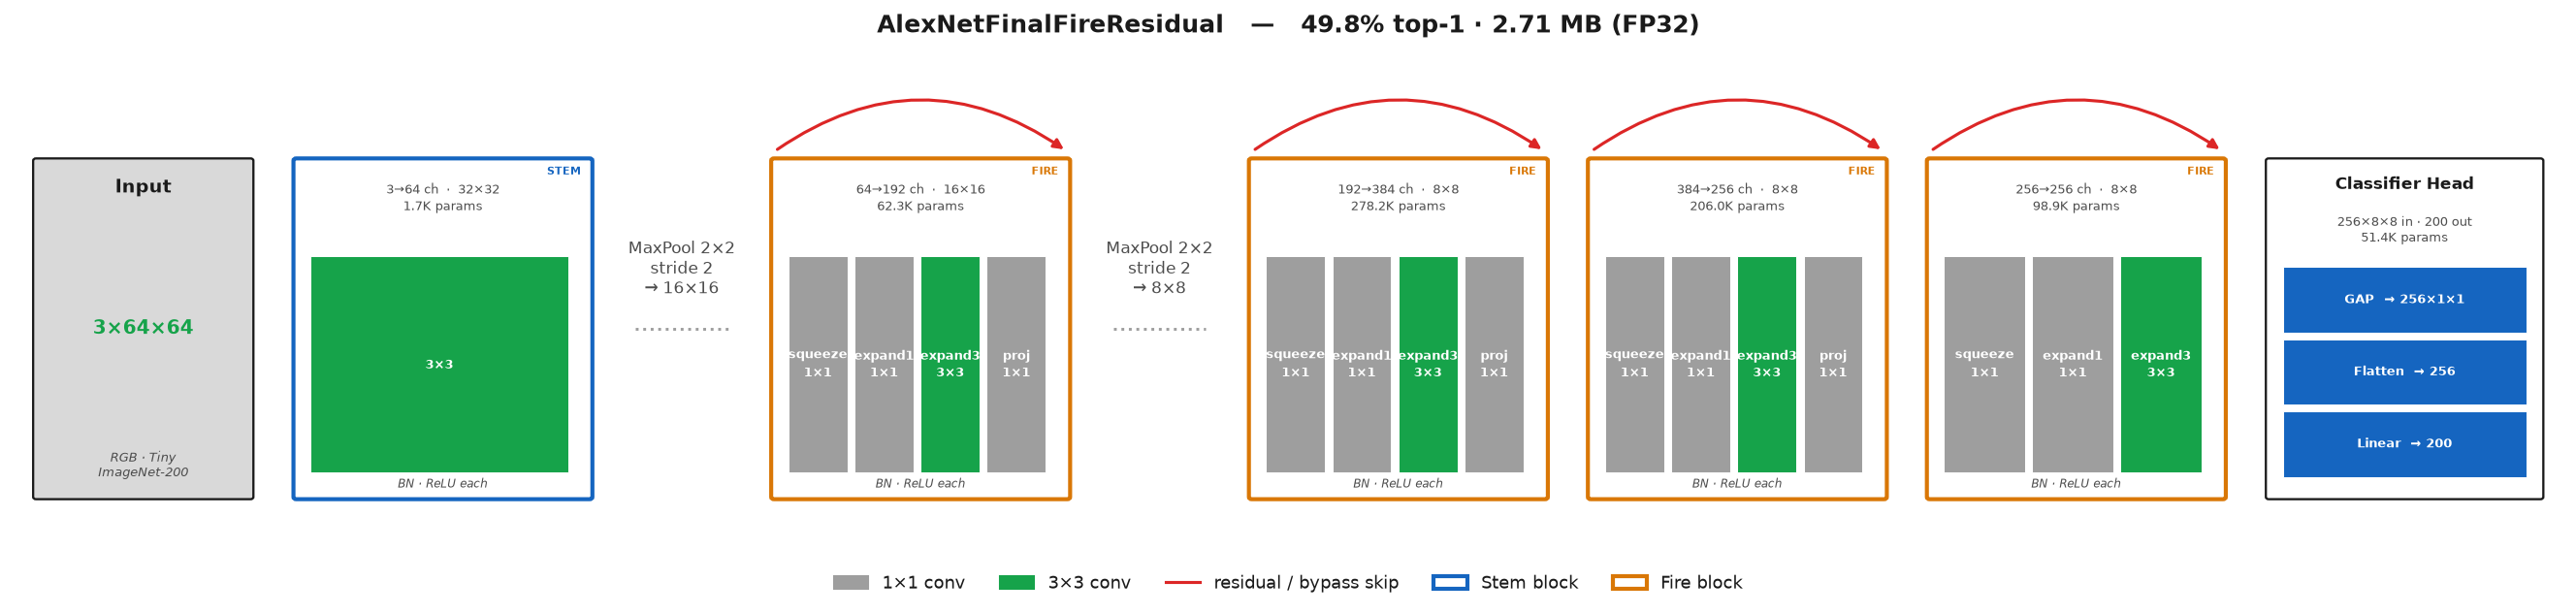

In [8]:
save_model_figure("alexnet_final_fire_residual", "AlexNetFinalFireResidual")

### AlexNetFireBypass (Phase 9)

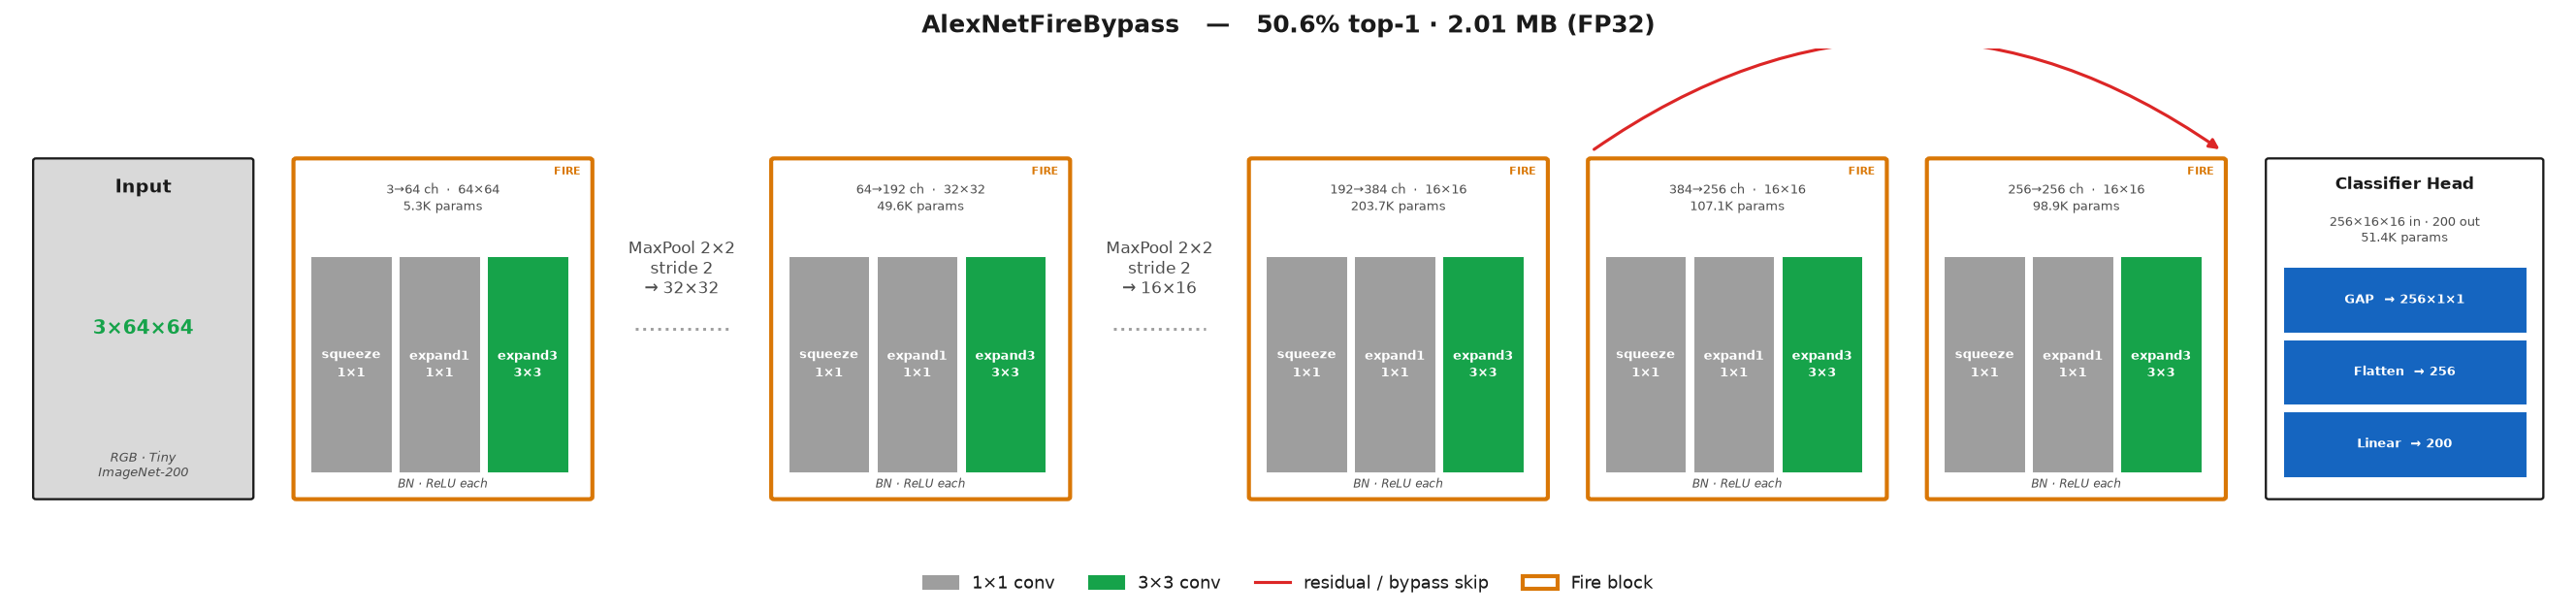

In [9]:
save_model_figure("alexnet_fire_bypass", "AlexNetFireBypass")

## Self-Check

In [10]:
_bn_blocks = [s for s in STAGES["alexnet_bottleneck"] if s["type"] != "pool"]
assert len(_bn_blocks) == 5, f"expected 5 AlexNetBottleneck blocks, got {len(_bn_blocks)}"
assert all(s["residual_span"] == 0 for s in _bn_blocks), "AlexNetBottleneck should have no residual connections"
assert all(s["out_shape"][0] == s["out_ch"] for s in _bn_blocks), "hooked output channels should match module out_ch"

_fb_stages = STAGES["alexnet_fire_bypass"]
_fb_blocks = [s for s in _fb_stages if s["type"] != "pool"]
assert len(_fb_blocks) == 5, f"expected 5 AlexNetFireBypass fire stages, got {len(_fb_blocks)}"
assert _fb_stages[-1]["residual_span"] == 2, "expected the bypass arc to span the fire4->fire5 pair"
assert sum(s["residual_span"] > 0 for s in _fb_blocks) == 1, "AlexNetFireBypass should have exactly one bypass arc"

# 64x64 input, 1 stride-2 conv + 2 stride-2 maxpools in AlexNetBottleneck's features -> 8x8 by the last block
assert _bn_blocks[-1]["out_shape"][1:] == (8, 8), f"expected 8x8 at the last stage, got {_bn_blocks[-1]['out_shape'][1:]}"

# Regression guard: out_ch must come from the real (concatenated) forward-pass shape, not the
# last conv's out_channels -- that undercounts every Fire-style block (expand1 + expand3 concat).
_fire_out_chs = [s["out_ch"] for s in STAGES["alexnet_fire"] if s["type"] != "pool"]
assert _fire_out_chs == [64, 192, 384, 256, 256], f"AlexNetFire out_ch progression should be 64,192,384,256,256 -- got {_fire_out_chs}"
_last_resblock = [s for s in STAGES["alexnet_final_fire_residual"] if s["type"] != "pool"][-1]
assert _last_resblock["out_ch"] == 256, f"last FireResBlock (Identity shortcut, in_ch==out_ch) should report out_ch=256, got {_last_resblock['out_ch']}"

print("Self-check passed: stage extraction + real output shapes match known topology.")

Self-check passed: stage extraction + real output shapes match known topology.
